# Task 3: Customer Churn / Sales Trend Analysis

## Project Overview

In this project, I will perform an end-to-end analysis of an e-commerce sales dataset.

The objective is to understand sales performance, customer behavior, revenue trends, and customer segments.

The analysis will include data cleaning, feature engineering, date extraction, pivot tables, trend calculations, customer segmentation, and business recommendations.

## Objectives

- Clean and prepare the e-commerce transaction data.
- Create useful features from transaction dates.
- Calculate revenue for individual transactions.
- Analyze monthly and yearly sales trends.
- Identify top-performing products and customer segments.
- Create pivot tables for business analysis.
- Identify inactive customers using a simple recency-based approach.
- Generate actionable business recommendations.

## Business Questions

1. How does revenue change over time?
2. Which products generate the most revenue?
3. Which customer segments contribute the most revenue?
4. Which countries generate the most sales?
5. How many customers are inactive?
6. Which customer groups should receive additional attention?
7. What actions could improve sales and customer retention?

## 1. Importing Required Libraries

I use Pandas and NumPy for data manipulation and numerical analysis.

Matplotlib and Seaborn are used to visualize sales trends, customer segments, and revenue patterns.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the E-Commerce Dataset

The Online Retail dataset contains transaction-level information from an e-commerce business.

Important fields include:

- Invoice number
- Product description
- Quantity purchased
- Invoice date
- Unit price
- Customer ID
- Country

These fields allow us to calculate revenue and analyze customer purchasing behavior.

In [104]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial Dataset Inspection

Before performing analysis, I inspect the structure of the dataset.

This helps identify data types, missing values, duplicate records, and unusual values that may affect the analysis.

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [106]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## 4. Missing Value Analysis

Missing values can affect customer and revenue analysis.

I calculate the number and percentage of missing values for each column before deciding how they should be handled.

In [107]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


## 5. Data Cleaning

For customer-level analysis, CustomerID is important because it identifies individual customers.

Rows without a CustomerID cannot reliably be associated with a customer, so they will be removed.

I also remove duplicate transactions and inspect cancelled transactions separately.

In [108]:
print("Original shape:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Original shape: (541909, 8)
After removing duplicates: (536641, 8)


In [109]:
df = df.dropna(subset=["CustomerID"])

print("After removing rows without CustomerID:", df.shape)

After removing rows without CustomerID: (401604, 8)


## 6. Date Feature Engineering

The InvoiceDate column contains transaction date and time information.

I convert it to Pandas datetime format so that year, month, quarter, day, and other time-based features can be extracted.

In [110]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[ns]


## 7. Revenue Feature Engineering

Revenue for each transaction is calculated as:

Revenue = Quantity × UnitPrice

Creating a revenue column allows the analysis to focus on monetary performance rather than only transaction volume.

In [111]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df[[
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 8. Extracting Date Features

I extract several time-related features from InvoiceDate.

These features allow sales to be analyzed at different time levels, including:

- Year
- Month
- Quarter
- Day of week
- Date

These features are useful for identifying seasonal and time-based sales trends.

In [112]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Date"] = df["InvoiceDate"].dt.date

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Quarter,Day,DayOfWeek,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,4,1,Wednesday,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,4,1,Wednesday,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,4,1,Wednesday,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,4,1,Wednesday,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,4,1,Wednesday,2010-12-01


## 9. Creating a Monthly Time Period

A Year-Month feature is created to make monthly revenue analysis easier.

Using a combined year and month prevents January from different years from being treated as the same period.

In [113]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

df[[
    "InvoiceDate",
    "Year",
    "Month",
    "Quarter",
    "YearMonth"
]].head()

,InvoiceDate,Year,Month,Quarter,YearMonth
0,2010-12-01 08:26:00,2010,12,4,2010-12
1,2010-12-01 08:26:00,2010,12,4,2010-12
2,2010-12-01 08:26:00,2010,12,4,2010-12
3,2010-12-01 08:26:00,2010,12,4,2010-12
4,2010-12-01 08:26:00,2010,12,4,2010-12


## 10. Handling Invalid Transactions

Before calculating business metrics, I check for negative quantities and zero or negative prices.

Negative quantities can represent cancelled or returned transactions. For the primary sales trend analysis, I focus on positive-quantity transactions.

In [114]:
print("Negative quantity records:", (df["Quantity"] < 0).sum())
print("Zero or negative price records:", (df["UnitPrice"] <= 0).sum())

Negative quantity records: 8872
Zero or negative price records: 40


In [115]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Original records:", len(df))
print("Valid sales records:", len(sales_df))

Original records: 401604
Valid sales records: 392692


## 11. Overall Sales Performance

I calculate basic business metrics including total revenue, number of transactions, number of customers, and quantity sold.

These metrics provide a high-level overview of the business.

In [116]:
total_revenue = sales_df["Revenue"].sum()
total_transactions = sales_df["InvoiceNo"].nunique()
total_customers = sales_df["CustomerID"].nunique()
total_quantity = sales_df["Quantity"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Items Sold: {total_quantity:,}")

Total Revenue: £8,887,208.89
Total Transactions: 18,532
Total Customers: 4,338
Total Items Sold: 5,152,002


## 12. Monthly Revenue Trend

Monthly revenue is calculated using a group-by operation.

Analyzing revenue over time helps identify growth patterns, seasonal changes, and periods of unusually high or low sales.

In [117]:
monthly_revenue = (
    sales_df
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


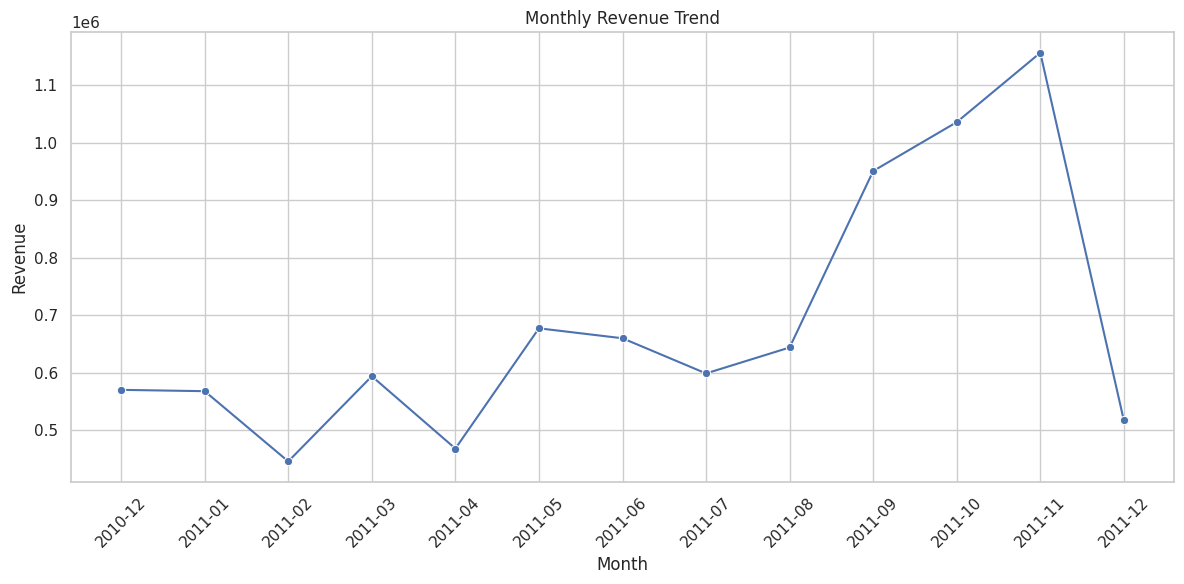

In [120]:
# Convert YearMonth to string for plotting
monthly_revenue_plot = monthly_revenue.copy()
monthly_revenue_plot["YearMonth"] = (
    monthly_revenue_plot["YearMonth"].astype(str)
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue_plot,
    x="YearMonth",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Monthly Revenue Growth

I calculate month-over-month revenue growth to understand how sales performance changes between consecutive months.

This metric can help identify periods of accelerating or declining revenue.

In [121]:
monthly_revenue["RevenueGrowth_%"] = (
    monthly_revenue["Revenue"]
    .pct_change()
    .mul(100)
)

monthly_revenue

,YearMonth,Revenue,RevenueGrowth_%
0,2010-12,570422.730,NaN
1,2011-01,568101.310,-0.406965
2,2011-02,446084.920,-21.477928
3,2011-03,594081.760,33.176831
4,2011-04,468374.331,-21.159954
5,2011-05,677355.150,44.618333
6,2011-06,660046.050,-2.555395
7,2011-07,598962.901,-9.254377
8,2011-08,644051.040,7.527701
9,2011-09,950690.202,47.611003


## 14. Quarterly Revenue Analysis

Quarterly aggregation provides a higher-level view of business performance.

I group revenue by year and quarter to identify broader seasonal patterns.

In [122]:
quarterly_revenue = (
    sales_df
    .groupby(["Year", "Quarter"])["Revenue"]
    .sum()
    .reset_index()
)

quarterly_revenue

,Year,Quarter,Revenue
0,2010,4,570422.730
1,2011,1,1608267.990
2,2011,2,1805775.531
3,2011,3,2193704.143
4,2011,4,2709038.500


## 15. Pivot Table: Revenue by Country and Month

Pivot tables provide a compact way to summarize large datasets.

Here, I create a pivot table showing revenue by country and month. This allows different geographic markets and their monthly performance to be compared.

In [123]:
country_month_pivot = pd.pivot_table(
    sales_df,
    values="Revenue",
    index="Country",
    columns="Month",
    aggfunc="sum",
    fill_value=0
)

country_month_pivot

Month,1,2,3,4,5,6,7,8,9,10,11,12
Country,,,,,,,,,,,,
Australia,9017.71,14695.42,17223.99,771.600,13638.41,25187.77,4964.380,22489.20,5106.730,17150.53,7242.72,965.35
Austria,0.00,518.36,1708.12,680.780,1249.43,0.00,1191.950,1516.08,0.000,1043.78,1329.78,960.40
Bahrain,0.00,0.00,0.00,0.000,548.40,0.00,0.000,0.00,0.000,0.00,0.00,0.00
Belgium,1200.20,2181.07,3351.98,1989.480,2732.40,4274.82,2475.570,3554.02,4208.020,5685.38,6315.76,3227.64
Brazil,0.00,0.00,0.00,1143.600,0.00,0.00,0.000,0.00,0.000,0.00,0.00,0.00
Canada,0.00,0.00,140.54,0.000,534.24,1171.46,1768.580,51.56,0.000,0.00,0.00,0.00
Channel Islands,675.58,1784.71,3509.33,293.000,1207.24,2060.03,0.000,4886.88,1323.750,2623.32,1514.77,561.93
Cyprus,547.50,4334.24,938.39,0.000,0.00,1109.32,0.000,0.00,196.350,4350.32,439.66,1587.07
Czech Republic,0.00,549.26,0.00,0.000,0.00,0.00,0.000,0.00,0.000,277.48,0.00,0.00


## 16. Top Products by Revenue

Product-level analysis helps identify which products contribute the most revenue.

I calculate total revenue for each product and rank the products from highest to lowest revenue.

In [124]:
top_products = (
    sales_df
    .groupby("Description")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

top_products.head(10)

,Revenue,Quantity,Transactions
Description,,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
REGENCY CAKESTAND 3 TIER,142264.75,12374,1703
WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
JUMBO BAG RED RETROSPOT,85040.54,46078,1600
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
POSTAGE,77803.96,3120,1099
PARTY BUNTING,68785.23,15279,1379
ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
Manual,53419.93,6933,253


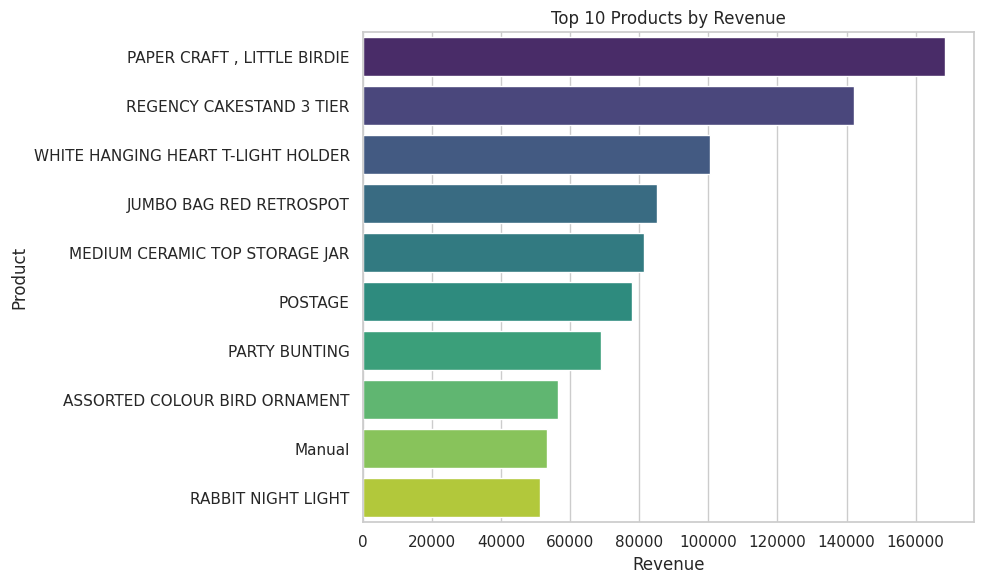

In [125]:
top_10_products = top_products.head(10).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_products,
    x="Revenue",
    y="Description",
    hue="Description",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## 17. Top Countries by Revenue

Geographic analysis helps identify the markets that contribute most to total revenue.

I calculate total revenue for each country and rank the results.

In [126]:
country_sales = (
    sales_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_sales.head(10)

,Revenue,Customers,Transactions
Country,,,
United Kingdom,7285024.644,3920,16646
Netherlands,285446.340,9,94
EIRE,265262.460,3,260
Germany,228678.400,94,457
France,208934.310,87,389
Australia,138453.810,9,57
Spain,61558.560,30,90
Switzerland,56443.950,21,51
Belgium,41196.340,25,98


## 18. Customer Segmentation by Revenue

Customer-level revenue is calculated to identify high-value customers.

This provides a simple business segmentation based on total customer spending.

In [127]:
customer_sales = (
    sales_df
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsPurchased=("Quantity", "sum"),
        LastPurchase=("InvoiceDate", "max")
    )
    .sort_values("Revenue", ascending=False)
)

customer_sales.head(10)

,Revenue,Orders,ItemsPurchased,LastPurchase
CustomerID,,,,
14646.0,280206.02,73,196915,2011-12-08 12:12:00
18102.0,259657.30,60,64124,2011-12-09 11:50:00
17450.0,194390.79,46,69973,2011-12-01 13:29:00
16446.0,168472.50,2,80997,2011-12-09 09:15:00
14911.0,143711.17,201,80240,2011-12-08 15:54:00
12415.0,124914.53,21,77374,2011-11-15 14:22:00
14156.0,117210.08,55,57768,2011-11-30 10:54:00
17511.0,91062.38,31,64549,2011-12-07 10:12:00
16029.0,80850.84,63,40108,2011-11-01 10:27:00


## 19. Customer Segmentation

Customers are divided into simple revenue-based segments.

The segmentation is intended as a practical business-analysis example:

- **High Value:** Customers with relatively high total revenue.
- **Medium Value:** Customers with moderate revenue.
- **Low Value:** Customers with lower revenue.

These groups can be used to design different marketing and retention strategies.

In [128]:
customer_sales["CustomerSegment"] = pd.qcut(
    customer_sales["Revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

customer_sales.head()

,Revenue,Orders,ItemsPurchased,LastPurchase,CustomerSegment
CustomerID,,,,,
14646.0,280206.02,73,196915,2011-12-08 12:12:00,High Value
18102.0,259657.30,60,64124,2011-12-09 11:50:00,High Value
17450.0,194390.79,46,69973,2011-12-01 13:29:00,High Value
16446.0,168472.50,2,80997,2011-12-09 09:15:00,High Value
14911.0,143711.17,201,80240,2011-12-08 15:54:00,High Value


## 20. Customer Segment Summary

I summarize each customer segment by calculating the number of customers, total revenue, and average revenue per customer.

This helps determine which customer groups contribute most to the business.

In [129]:
segment_summary = (
    customer_sales
    .groupby("CustomerSegment", observed=True)
    .agg(
        Customers=("Revenue", "count"),
        TotalRevenue=("Revenue", "sum"),
        AverageRevenue=("Revenue", "mean")
    )
)

segment_summary

,Customers,TotalRevenue,AverageRevenue
CustomerSegment,,,
Low Value,1446,317006.670,219.230062
Medium Value,1446,1024481.293,708.493287
High Value,1446,7545720.931,5218.340893


## 21. Customer Inactivity / Churn-Style Analysis

The dataset does not contain an explicit churn label.

Therefore, instead of claiming that a customer has definitively churned, I use a simple recency-based inactivity indicator.

The most recent transaction date in the dataset is used as the analysis reference date.

Customers whose most recent purchase occurred more than 90 days before the reference date are classified as "Inactive".

This is an analytical proxy for potential churn and should not be interpreted as confirmed customer churn.

In [130]:
reference_date = sales_df["InvoiceDate"].max()

customer_sales["DaysSinceLastPurchase"] = (
    reference_date - customer_sales["LastPurchase"]
).dt.days

customer_sales["ActivityStatus"] = np.where(
    customer_sales["DaysSinceLastPurchase"] > 90,
    "Inactive",
    "Active"
)

customer_sales.head()

,Revenue,Orders,ItemsPurchased,LastPurchase,CustomerSegment,DaysSinceLastPurchase,ActivityStatus
CustomerID,,,,,,,
14646.0,280206.02,73,196915,2011-12-08 12:12:00,High Value,1,Active
18102.0,259657.30,60,64124,2011-12-09 11:50:00,High Value,0,Active
17450.0,194390.79,46,69973,2011-12-01 13:29:00,High Value,7,Active
16446.0,168472.50,2,80997,2011-12-09 09:15:00,High Value,0,Active
14911.0,143711.17,201,80240,2011-12-08 15:54:00,High Value,0,Active


## 22. Active vs Inactive Customer Analysis

I compare the number of active and inactive customers.

This provides a simple view of customer retention and helps identify the size of the customer base that may require re-engagement.

In [131]:
activity_summary = (
    customer_sales["ActivityStatus"]
    .value_counts()
    .reset_index()
)

activity_summary.columns = ["ActivityStatus", "Customers"]

activity_summary

,ActivityStatus,Customers
0,Active,2893
1,Inactive,1445


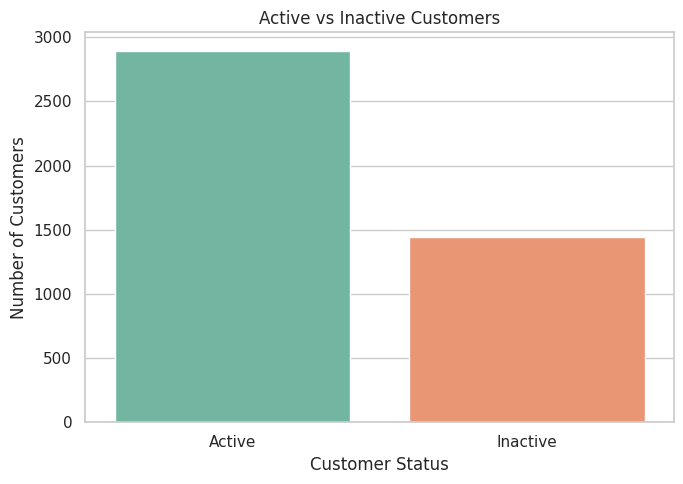

In [132]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=activity_summary,
    x="ActivityStatus",
    y="Customers",
    hue="ActivityStatus",
    palette="Set2",
    legend=False
)

plt.title("Active vs Inactive Customers")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 23. Customer Revenue vs Number of Orders

A scatter plot can help explore whether customers who place more orders tend to generate higher revenue.

Each point represents a customer.

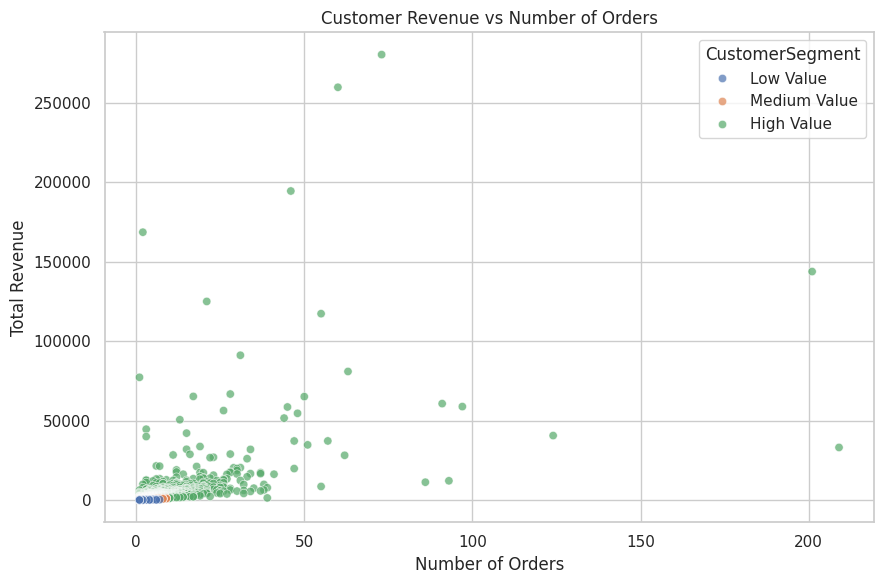

In [133]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_sales,
    x="Orders",
    y="Revenue",
    hue="CustomerSegment",
    alpha=0.7
)

plt.title("Customer Revenue vs Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

## 24. Sales by Day of the Week

I analyze revenue by day of the week to identify potential differences in purchasing activity across weekdays and weekends.

This can help businesses plan promotions, staffing, and marketing campaigns.

In [134]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    sales_df
    .groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(weekday_order)
)

weekday_sales

,Revenue
DayOfWeek,
Monday,1363604.401
Tuesday,1697733.801
Wednesday,1584283.830
Thursday,1973015.730
Friday,1483080.811
Saturday,NaN
Sunday,785490.321


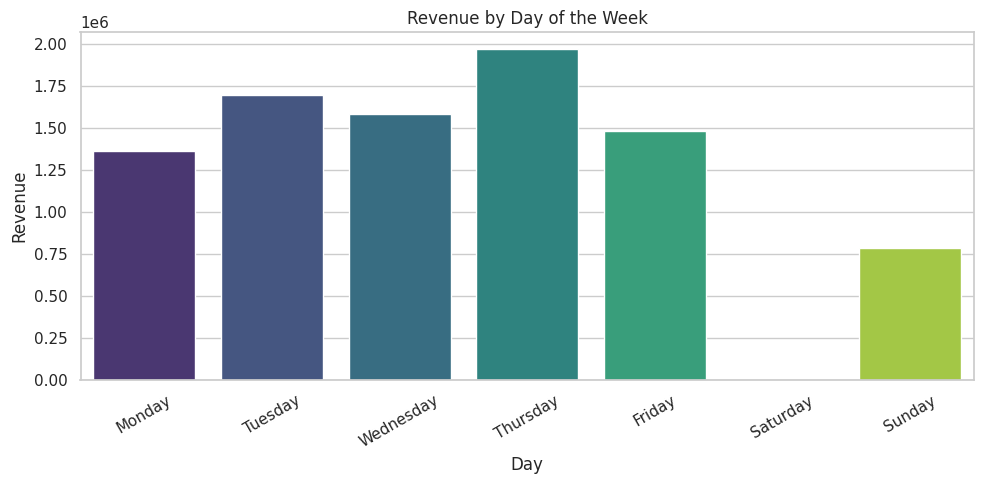

In [135]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    hue=weekday_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 25. Business Recommendations

Based on the sales trends, customer segmentation, product performance, and customer activity analysis, the following business recommendations can be considered:

### 1. Focus on High-Value Customers

High-value customers contribute a significant amount of revenue. The business can consider loyalty programs, personalized offers, and early access to new products for this segment.

### 2. Re-engage Inactive Customers

Customers classified as inactive based on the 90-day recency threshold can be targeted with personalized email campaigns, discounts, or product recommendations.

### 3. Promote High-Performing Products

Products generating high revenue can receive greater visibility through homepage placement, bundles, and promotional campaigns.

### 4. Investigate Low-Performing Products

Products with consistently low sales can be reviewed for pricing, demand, product positioning, or inventory decisions.

### 5. Monitor Monthly Revenue Trends

Monthly revenue and month-over-month growth should be monitored regularly to identify seasonal patterns and periods of declining performance.

### 6. Use Customer Segmentation

Different customer segments should receive different marketing strategies instead of using the same campaign for every customer.

### 7. Geographic Expansion

Countries with strong revenue and customer activity can be studied to identify opportunities for expansion, while lower-performing markets can be evaluated before additional investment.

### Important Limitation

The inactivity analysis is a simple recency-based proxy and does not represent a formally trained churn prediction model. Additional information such as customer tenure, marketing interactions, refunds, and future purchase behavior would be required for a more rigorous churn prediction system.

# 26. Conclusion

This project demonstrated an end-to-end e-commerce sales analysis using Python and Pandas.

The analysis included:

- Data cleaning and preparation.
- Feature engineering.
- Date and time feature extraction.
- Revenue calculation.
- Monthly and quarterly sales analysis.
- Month-over-month growth calculation.
- Pivot table analysis.
- Product-level analysis.
- Geographic analysis.
- Customer segmentation.
- Customer inactivity analysis.
- Data visualization.
- Business recommendations.

The analysis demonstrates how transaction-level data can be transformed into useful business intelligence.

The results can help businesses understand revenue trends, identify valuable customer groups, monitor product performance, and develop targeted customer-retention strategies.